# PAMA-seq genus level differential analysis 

#### by Jingjing Cheng and Xiangpeng Li

## Goal
Compare salt water genus vs river water genus to identify sea enriched genus and river enriched genus. 

## PAMA-seq data saved in folder: 
  `/data10/xli/raw_data/miseq_202512_jingjing/OL_PAMA_rename/`

## 16S data saved in folder: 
  `/data10/xli/raw_data/miseq_202512_jingjing/OL_18S_rename/`
  
  
## Analysis Folder 
`/data10/xli/project/pama-seq/OL_dif/`

In [149]:
import os
out_dir = '/data10/xli/project/pama-seq/OL_dif/'
os.makedirs(out_dir, exist_ok=True)

In [150]:
!ls /data10/xli/project/pama-seq/OL_dif/

16S_long_table.csv	    itol_kingdom.txt   pama_long_table.csv
18s_long_table.csv	    itol_sig_16s.txt   volcano_3methods_labeled.pdf
genus_ra_ttest_results.csv  itol_sig_18s.txt   volcano_3methods_labeled.png
itol_kingdom_clade.txt	    itol_sig_pama.txt  volcano_3methods_labeled.svg


In [151]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

In [152]:
longp_full = pd.read_csv(out_dir+ 'pama_long_table.csv', index_col = 0)

long18_full = pd.read_csv(out_dir+ '18s_long_table.csv', index_col = 0)

long16_full = pd.read_csv(out_dir+ '16S_long_table.csv', index_col = 0)

In [153]:
long_all = pd.concat([long16_full, long18_full, longp_full], ignore_index=True)

In [154]:
long_all[long_all['Kingdom']=="Unassigned"]

,FeatureID,SampleID,Count,Kingdom,Phylum,Class,Order,Family,Genus,Species,Method,core
2246,9e70ddace0d7b13344829818912df3a8,Ocean-lake-1a,7.0,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,18S,1a
2392,90693eab725601515dc8fbbfa01f65b3,Ocean-lake-1a,3.0,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,18S,1a
2583,9e70ddace0d7b13344829818912df3a8,Ocean-lake-1b,17.0,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,18S,1b
2714,90693eab725601515dc8fbbfa01f65b3,Ocean-lake-1b,2.0,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,18S,1b
3239,9e70ddace0d7b13344829818912df3a8,Ocean-lake-2b,39.0,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,18S,2b
3563,6187afeb2eef1ab2bc3f6c1754be38e7,Ocean-lake-3a,25.0,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,18S,3a
3670,91842611ba85f6da6b09df8a1e999a24,Ocean-lake-3a,20.0,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,18S,3a
3828,d7fc77741bc2f8704f8c537e882dc5a1,Ocean-lake-3a,6.0,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,18S,3a
3875,138055b000f64ff977e556b99c53edbc,Ocean-lake-3a,6.0,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,18S,3a
3915,39339eba57752421c30d9455c76c51e9,Ocean-lake-3a,8.0,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,18S,3a


In [155]:
long_all.drop(['SampleID','Species'], axis =1).head

<bound method NDFrame.head of                               FeatureID  Count   Kingdom           Phylum  \
0      7a67662a35c24ad02e1a9c553f695752  328.0  Bacteria    Cyanobacteria   
1      76cc4e4423fe1d58c82a861e79323bd7  317.0  Bacteria    Cyanobacteria   
2      2e06738ba1ef7e3f75f0ed55e95a2bb8  261.0  Bacteria    Cyanobacteria   
3      e2fc9fa8e63d8276f399c93709e08fd5  231.0  Bacteria    Cyanobacteria   
4      c3caa6e2a48f3f2ab0b049512dc8ccda  245.0  Bacteria    Cyanobacteria   
...                                 ...    ...       ...              ...   
20347  7418ae3286959480b6dbd86c90eaba0e    1.0  Bacteria   Proteobacteria   
20348  070ac953c0785fe3d592eb6e6abaf2c3    1.0  Bacteria   Proteobacteria   
20349  d8a7e148a30a33e91979b2ce273a8d6e    1.0  Bacteria   Proteobacteria   
20350  1e9990f68bc40caaca12659b31040bdd    1.0  Bacteria  Planctomycetota   
20351  954a1f01fffa0fee2e76972bc03435ca    1.0  Bacteria   Proteobacteria   

                     Class            Order  

In [156]:
df = long_all.pivot_table(
    index=["FeatureID", "Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Method"],
    columns="core",
    values="Count",
    aggfunc="sum",
    fill_value=0
).reset_index()

In [157]:

# # Remove 'uncultured' and 'Unassigned' taxa
df = df[~df['Genus'].str.contains('uncultured|Unassigned', case=False, na=False)]

df.head()

core,FeatureID,Kingdom,Phylum,Class,Order,Family,Genus,Method,1a,1b,2a,2b,3a,3b,4a,4b
0,0001573d08c69d883a9704da1c76ca56,Bacteria,Bdellovibrionota,Bdellovibrionia,Bdellovibrionales,Bdellovibrionaceae,OM27_clade,16S,0.0,0.0,0.0,0.0,0.0,0.0,14.0,0.0
2,000f1aa840ed208b29446c2dcb4aebb4,Bacteria,Proteobacteria,Gammaproteobacteria,UBA10353_marine_group,UBA10353_marine_group,UBA10353_marine_group,PAMA,0.0,0.0,0.0,0.0,54.0,0.0,0.0,46.0
4,0015bbafc84a8a8d92214d995eeb1482,Bacteria,Calditrichota,Calditrichia,Calditrichales,Calditrichaceae,Calditrichaceae,PAMA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.0
6,001bfe9933674a09b4fed2c4bceb38ad,Bacteria,Actinobacteriota,MB-A2-108,MB-A2-108,MB-A2-108,MB-A2-108,PAMA,0.0,27.0,0.0,0.0,0.0,0.0,0.0,0.0
7,001d08fe6d5575f318d37f9ad8b630a6,Bacteria,Fusobacteriota,Fusobacteriia,Fusobacteriales,Fusobacteriaceae,Propionigenium,16S,0.0,0.0,0.0,0.0,57.0,0.0,0.0,0.0


In [158]:
# Aggregate counts to genus level by method and create unique taxonomy-based IDs

tax_cols = ['Kingdom','Phylum','Class','Order','Family','Genus']
sample_cols = ['1a','1b', '2a', '2b', '3a', '3b', '4a', '4b']

# # Group by method and taxonomy hierarchy and sum counts for each genus
df_genus = (df.groupby(['Method'] + tax_cols)[sample_cols]
              .sum()
              .reset_index())

# # Generate unique tip IDs
df_genus['tip'] = df_genus[tax_cols].astype(str).agg('|'.join, axis=1)

print("Aggregation complete，shape:", df_genus.shape)
print(df_genus['Method'].value_counts())

Aggregation complete，shape: (1385, 16)
Method
PAMA    967
16S     265
18S     153
Name: count, dtype: int64


In [159]:
# Perform genus-level differential analysis using log-transformed relative abundance and Welch’s t-test


def run_ra_ttest(df_genus, method_name):

    river_cols = ['1a','1b', '2a', '2b']
    ocean_cols = ['3a', '3b', '4a', '4b']
    all_cols = river_cols + ocean_cols

    sub = df_genus[df_genus['Method'] == method_name].copy()
    sub = sub[sub[all_cols].sum(axis=1) > 0]
    sub = sub.set_index('tip')

    X = sub[all_cols].astype(float)

    # convert to relative abundance (safe)
    col_sums = X.sum(axis=0)
    col_sums[col_sums == 0] = 1
    X_ra = X.div(col_sums, axis=1)

    # log transform
    X_log = np.log10(X_ra + 1e-6)

    results = []
    for tip in X_log.index:
        river_vals = X_log.loc[tip, river_cols].values
        ocean_vals = X_log.loc[tip, ocean_cols].values

        t_stat, p_val = stats.ttest_ind(
            ocean_vals, river_vals,
            equal_var=False,
            nan_policy='omit'
        )

        lfc = ocean_vals.mean() - river_vals.mean()

        results.append({
            'tip': tip,
            'lfc': lfc,
            'p': p_val,
            'direction': 'Ocean' if lfc > 0 else 'River'
        })

    res_df = pd.DataFrame(results)

    _, q_vals, _, _ = multipletests(res_df['p'].fillna(1), method='fdr_bh')
    res_df['q'] = q_vals
    res_df['Method'] = method_name
    res_df['significant'] = res_df['q'] < 0.05

    return res_df

In [160]:
df_genus['Method'].unique()

array(['16S', '18S', 'PAMA'], dtype=object)

In [161]:
# Run analysis
res_pama = run_ra_ttest(df_genus, 'PAMA')
res_16s  = run_ra_ttest(df_genus, '16S')
res_18s  = run_ra_ttest(df_genus, '18S')

# Merge
res_all = pd.concat([res_pama, res_16s, res_18s], ignore_index=True)

# Summary
summary = res_all.groupby('Method').apply(
    lambda x: pd.Series({
        'total_genus': len(x),
        'significant': x['significant'].sum(),
        'ocean_enriched': ((x['significant']) & (x['direction'] == 'Ocean')).sum(),
        'river_enriched': ((x['significant']) & (x['direction'] == 'River')).sum()
    })
).reset_index()

print(summary)

# Save
res_all.to_csv(out_dir+"genus_ra_ttest_results.csv", index=False)
res_all

  Method  total_genus  significant  ocean_enriched  river_enriched
0    16S          265           59              33              26
1    18S          153           47              39               8
2   PAMA          967          164             137              27


,tip,lfc,p,direction,q,Method,significant
0,Archaea|Altiarchaeota|Altiarchaeia|Altiarchaea...,0.576071,3.910022e-01,Ocean,0.421046,PAMA,False
1,Archaea|Asgardarchaeota|Heimdallarchaeia|Heimd...,0.576946,3.910022e-01,Ocean,0.421046,PAMA,False
2,Archaea|Crenarchaeota|Bathyarchaeia|Bathyarcha...,-0.261372,7.655351e-01,River,0.782529,PAMA,False
3,Archaea|Halobacterota|Halobacteria|Halobactera...,0.524450,3.910022e-01,Ocean,0.421046,PAMA,False
4,Archaea|Halobacterota|Methanosarcinia|Methanos...,-0.602868,3.910022e-01,River,0.421046,PAMA,False
...,...,...,...,...,...,...,...
1380,Eukaryota|Retaria|Acantharia|Symphyacanthida|S...,4.050360,5.665753e-07,Ocean,0.000022,18S,True
1381,Eukaryota|Retaria|Foraminifera|Rotaliida|Rotal...,1.211277,1.836395e-01,Ocean,0.305250,18S,False
1382,Eukaryota|Rigifilida|Rigifilida|Rigifilida|Rig...,-0.477991,3.910022e-01,River,0.412575,18S,False
1383,Eukaryota|SA1-3C06|SA1-3C06|SA1-3C06|SA1-3C06|...,-0.474375,6.316895e-01,River,0.653030,18S,False


In [162]:
# List of significant genera
sig = res_all[res_all['significant'] == True].copy()

# Add taxonomy information back to the results
tax_info = df_genus[['tip'] + tax_cols].drop_duplicates()
sig = sig.merge(tax_info, on='tip', how='left')

# Identify top significant genera within each method
for method in ['PAMA', '16S', '18S']:
    sub = sig[sig['Method'] == method].sort_values('q')
    print(f"\n=== {method} (Sig.{len(sub)}) ===")
    print(sub[['Genus','lfc','q','direction']].head(10).to_string(index=False))


=== PAMA (Sig.164) ===
                 Genus      lfc        q direction
Sva0081_sediment_group 3.405015 0.000668     Ocean
      Thraustochytrium 3.518698 0.000709     Ocean
            Cyclotella 4.131122 0.000945     Ocean
   Syndiniales_Group_I 4.479388 0.000945     Ocean
             Muricauda 2.960354 0.001121     Ocean
   Bacteroidetes_BD2-2 2.762922 0.001121     Ocean
            Saprospira 2.125782 0.001121     Ocean
             Muriicola 2.903885 0.001121     Ocean
 UBA10353_marine_group 3.164859 0.001121     Ocean
                BD7-11 2.771277 0.001121     Ocean

=== 16S (Sig.59) ===
                Genus       lfc        q direction
           Litoricola  4.021439 0.000006     Ocean
CL500-29_marine_group -3.893162 0.000006     River
 Synechococcus_CC9902  4.741178 0.000006     Ocean
          Subgroup_10  3.826503 0.000007     Ocean
              FukuN57 -3.830142 0.000011     River
                CCD24 -4.008998 0.000011     River
        Sulfurifustis -3.814292 0.00

In [163]:
sub

,tip,lfc,p,direction,q,Method,significant,Kingdom,Phylum,Class,Order,Family,Genus
246,Eukaryota|Cryptophyceae|Cryptophyceae|Cryptomo...,4.618035,1.221432e-09,Ocean,1.868791e-07,18S,True,Eukaryota,Cryptophyceae,Cryptophyceae,Cryptomonadales,Cryptomonadales,Proteomonas
250,Eukaryota|Diatomea|Coscinodiscophytina|Coscino...,4.133068,8.309078e-08,Ocean,6.356445e-06,18S,True,Eukaryota,Diatomea,Coscinodiscophytina,Coscinodiscophytina,Rhizosolenids,Rhizosolenids
235,Eukaryota|Chlorophyta|Chlorodendrophyceae|Chlo...,4.513915,3.573149e-07,Ocean,1.822306e-05,18S,True,Eukaryota,Chlorophyta,Chlorodendrophyceae,Chlorodendrales,Chlorodendrales,Tetraselmis
269,Eukaryota|Retaria|Acantharia|Symphyacanthida|S...,4.050360,5.665753e-07,Ocean,2.167151e-05,18S,True,Eukaryota,Retaria,Acantharia,Symphyacanthida,Symphyacanthida,Amphibelone
268,Eukaryota|Prymnesiophyceae|Prymnesiophyceae|Pr...,3.353106,8.466177e-07,Ocean,2.345731e-05,18S,True,Eukaryota,Prymnesiophyceae,Prymnesiophyceae,Prymnesiales,Prymnesiales,OLI51059
225,Eukaryota|Annelida|Polychaeta|Opheliidae|Ophel...,4.523625,9.198945e-07,Ocean,2.345731e-05,18S,True,Eukaryota,Annelida,Polychaeta,Opheliidae,Opheliidae,Opheliidae
244,Eukaryota|Cryptophyceae|Cryptophyceae|Cryptomo...,4.316416,1.166843e-06,Ocean,2.550386e-05,18S,True,Eukaryota,Cryptophyceae,Cryptophyceae,Cryptomonadales,Cryptomonadales,Geminigera
256,Eukaryota|MAST-11|MAST-11|MAST-11|MAST-11|MAST-11,3.153894,2.067444e-06,Ocean,3.953987e-05,18S,True,Eukaryota,MAST-11,MAST-11,MAST-11,MAST-11,MAST-11
245,Eukaryota|Cryptophyceae|Cryptophyceae|Cryptomo...,-3.884404,3.781724e-06,River,5.050678e-05,18S,True,Eukaryota,Cryptophyceae,Cryptophyceae,Cryptomonadales,Cryptomonadales,Komma
241,Eukaryota|Cnidaria|Anthozoa|Actiniaria|Actinia...,5.076786,3.961316e-06,Ocean,5.050678e-05,18S,True,Eukaryota,Cnidaria,Anthozoa,Actiniaria,Actiniaria,Actiniaria


In [164]:
# Take the union of significant genera across the three methods
sig_tips = set(sig['tip'].unique())
print(f"Union of the three methods：{len(sig_tips)} Sig. tips")

# Tip sets for each method separately
tips_pama = set(sig[sig['Method']=='PAMA']['tip'])
tips_16s  = set(sig[sig['Method']=='16S']['tip'])
tips_18s  = set(sig[sig['Method']=='18S']['tip'])

print(f"pama unique：{len(tips_pama - tips_16s - tips_18s)}")
print(f"16s unique：{len(tips_16s - tips_pama - tips_18s)}")
print(f"18s unique：{len(tips_18s - tips_pama - tips_16s)}")
print(f"pama & 16s shared：{len(tips_pama & tips_16s)}")
print(f"pama & 18s shared：{len(tips_pama & tips_18s)}")
print(f"16s & 18s shared：{len(tips_16s & tips_18s)}")
print(f"three methods shared：{len(tips_pama & tips_16s & tips_18s)}")

Union of the three methods：234 Sig. tips
pama unique：129
16s unique：34
18s unique：35
pama & 16s shared：24
pama & 18s shared：11
16s & 18s shared：1
three methods shared：0


In [165]:
# All 234 significant tips
tip_list = sorted(sig_tips)

# Build annotation table
anno = []
for tip in tip_list:
    # Extract full taxonomy information across all 7 ranks
    tax_row = df_genus[df_genus['tip'] == tip][tax_cols].iloc[0]
    tax = {
        'Kingdom': tax_row['Kingdom'],
        'Phylum':  tax_row['Phylum'],
        'Class':   tax_row['Class'],
        'Order':   tax_row['Order'],
        'Family':  tax_row['Family'],
        'Genus':   tax_row['Genus'],
        'tip':     tip
    }
    
    # Annotate results for each method
    for method in ['PAMA', '16S', '18S']:
        row = sig[(sig['tip'] == tip) & (sig['Method'] == method)]
        if len(row) == 0:
            tax[method] = 'ND'
        else:
            tax[method] = row.iloc[0]['direction'][0]  # 'O' or 'L'
    
    anno.append(tax)

anno_df = pd.DataFrame(anno)
print("shape:", anno_df.shape)
print(anno_df[['Kingdom','Phylum','Class','Order','Family','Genus','PAMA', '16S', '18S']].head(10).to_string(index=False))

shape: (234, 10)
 Kingdom           Phylum               Class                   Order                   Family                 Genus PAMA 16S 18S
 Archaea Thermoplasmatota      Thermoplasmata         Marine_Group_II          Marine_Group_II       Marine_Group_II    O  ND  ND
Bacteria  Acidobacteriota      Acidobacteriae          Bryobacterales          Bryobacteraceae            Bryobacter    R  ND  ND
Bacteria  Acidobacteriota      Acidobacteriae              Subgroup_2               Subgroup_2            Subgroup_2    R  ND  ND
Bacteria  Acidobacteriota          Holophagae Acanthopleuribacterales Acanthopleuribacteraceae   Acanthopleuribacter    O  ND  ND
Bacteria  Acidobacteriota         Subgroup_26             Subgroup_26              Subgroup_26           Subgroup_26    O  ND  ND
Bacteria  Acidobacteriota Thermoanaerobaculia   Thermoanaerobaculales   Thermoanaerobaculaceae           Subgroup_10   ND   O  ND
Bacteria  Acidobacteriota    Vicinamibacteria      Vicinamibacterales    

In [166]:
anno_df.head(2)

,Kingdom,Phylum,Class,Order,Family,Genus,tip,PAMA,16S,18S
0,Archaea,Thermoplasmatota,Thermoplasmata,Marine_Group_II,Marine_Group_II,Marine_Group_II,Archaea|Thermoplasmatota|Thermoplasmata|Marine...,O,ND,ND
1,Bacteria,Acidobacteriota,Acidobacteriae,Bryobacterales,Bryobacteraceae,Bryobacter,Bacteria|Acidobacteriota|Acidobacteriae|Bryoba...,R,ND,ND


In [167]:
# Build a taxonomy-based phylogenetic tree from the 234 significant genera
# using the hierarchical taxonomy ranks (Kingdom → Phylum → Class → Order → Family → Genus)
# The tip labels match exactly with the iTOL annotation files generated above

from ete3 import Tree

def build_taxonomy_tree(anno_df, tax_cols):
    """
    Construct a nested Newick tree based on taxonomic hierarchy.
    Each unique path from Kingdom to Genus becomes a branch.
    Leaf node names are set to 'tip' (pipe-joined taxonomy string)
    to ensure uniqueness and consistency with iTOL annotation files.
    """
    root = Tree()
    root.name = "root"
    
    for _, row in anno_df.iterrows():
        current = root
        # Traverse each taxonomic rank and add nodes if not already present
        for rank in tax_cols[:-1]:  # Kingdom to Family
            name = str(row[rank])
            child_names = [c.name for c in current.children]
            if name not in child_names:
                current = current.add_child(name=name)
            else:
                current = current.get_children()[child_names.index(name)]
        
        # Set the leaf node as the unique tip ID (used in iTOL files)
        current.add_child(name=row['tip'])
    
    return root

# Define taxonomic rank columns (must match anno_df column names)
tax_cols = ['Kingdom', 'Phylum', 'Class', 'Order', 'Family', 'Genus']

# Build the tree from the 234 significant tips
tree = build_taxonomy_tree(anno_df, tax_cols)

# Save as Newick format for iTOL upload
tree.write(format=1, outfile="Sig_taxonomy_tree.nwk")
print("Saved: Sig_taxonomy_tree.nwk")
print(f"Total leaf nodes: {len(tree.get_leaves())}")  # Should be 234

Saved: Sig_taxonomy_tree.nwk
Total leaf nodes: 234


In [168]:
# Validate the generated tree to ensure consistency with iTOL annotation files
# Check 1: leaf count matches the number of significant tips (234)
# Check 2: all leaf names exist in the iTOL annotation tip list
# Check 3: print the first 5 leaf names for a quick sanity check

leaves = tree.get_leaves()
leaf_names = [l.name for l in leaves]

# Check total leaf count
print(f"Total leaves in tree: {len(leaf_names)}")  # Expected: 234

# Check all tips in anno_df are present in the tree
missing = set(anno_df['tip']) - set(leaf_names)
extra   = set(leaf_names) - set(anno_df['tip'])
print(f"Tips in anno_df but missing from tree: {len(missing)}")  # Expected: 0
print(f"Tips in tree but not in anno_df: {len(extra)}")          # Expected: 0

# Quick preview of first 5 leaf names
print("\nFirst 5 leaf names:")
for name in leaf_names[:5]:
    print(" ", name)

Total leaves in tree: 234
Tips in anno_df but missing from tree: 0
Tips in tree but not in anno_df: 0

First 5 leaf names:
  Archaea|Thermoplasmatota|Thermoplasmata|Marine_Group_II|Marine_Group_II|Marine_Group_II
  Bacteria|Acidobacteriota|Acidobacteriae|Bryobacterales|Bryobacteraceae|Bryobacter
  Bacteria|Acidobacteriota|Acidobacteriae|Subgroup_2|Subgroup_2|Subgroup_2
  Bacteria|Acidobacteriota|Holophagae|Acanthopleuribacterales|Acanthopleuribacteraceae|Acanthopleuribacter
  Bacteria|Acidobacteriota|Subgroup_26|Subgroup_26|Subgroup_26|Subgroup_26


In [169]:
color_map = {"O": "#d62728", "R": "#1f77b4", "ND": "#bdbdbd"}

def write_itol_strip(filename, method_col, label):
    lines = [
        "DATASET_COLORSTRIP",
        "SEPARATOR TAB",
        f"DATASET_LABEL\t{label}",
        "COLOR\t#000000",
        "STRIP_WIDTH\t30",
        "MARGIN\t3",
        "BORDER_WIDTH\t0",
        "SHOW_LABELS\t1",
        "LABEL_ROTATION\t45",
        "LABEL_SHIFT\t5",
        "LEGEND_TITLE\t{label}",
        "LEGEND_SHAPES\t1\t1\t1",
        "LEGEND_COLORS\t#d62728\t#1f77b4\t#bdbdbd",
        "LEGEND_LABELS\tOcean\triver\tND",
        "DATA"
    ]
    for _, row in anno_df.iterrows():
        color = color_map.get(row[method_col], "#bdbdbd")
        lines.append(f"{row['tip']}\t{color}\t{row[method_col]}")
    with open(filename, "w") as f:
        f.write("\n".join(lines))
    print(f"Saved: {filename}")

write_itol_strip(out_dir+"itol_sig_pama.txt", "PAMA", "PAMA-seq")
write_itol_strip(out_dir+"itol_sig_16s.txt",  "16S",  "16S")
write_itol_strip(out_dir+"itol_sig_18s.txt",  "18S",  "18S")

Saved: /data10/xli/project/pama-seq/OL_dif/itol_sig_pama.txt
Saved: /data10/xli/project/pama-seq/OL_dif/itol_sig_16s.txt
Saved: /data10/xli/project/pama-seq/OL_dif/itol_sig_18s.txt


In [170]:
kingdom_colors = {
    'Bacteria':  '#A8D5A2',
    'Eukaryota': '#F4C6A0',
    'Archaea':   '#C3B1E1'
}

In [171]:
lines = [
    "DATASET_COLORSTRIP",
    "SEPARATOR TAB",
    "DATASET_LABEL\tKingdom",
    "COLOR\t#000000",
    "STRIP_WIDTH\t120",
    "MARGIN\t5",
    "BORDER_WIDTH\t0",
    "DATA"
]

for _, row in anno_df.iterrows():
    kingdom = row['Kingdom']
    color = kingdom_colors.get(kingdom, '#DDDDDD')
    lines.append(f"{row['tip']}\t{color}\t{kingdom}")

with open(out_dir+"itol_kingdom.txt", "w") as f:
    f.write("\n".join(lines))

# Use DATASET_BINARY to label clades internally
label_lines = [
    "TREE_COLORS",
    "SEPARATOR TAB",
    "DATA"
]

for kingdom, color in kingdom_colors.items():
    subset = anno_df[anno_df['Kingdom'] == kingdom]
    if len(subset) == 0:
        continue
    first_tip = subset.iloc[0]['tip']
    last_tip  = subset.iloc[-1]['tip']
    label_lines.append(f"{first_tip}|{last_tip}\tlabel_background\t{color}")
    label_lines.append(f"{first_tip}|{last_tip}\tlabel\t{kingdom}\t#000000\tbold\t4")

with open(out_dir+"itol_kingdom_clade.txt", "w") as f:
    f.write("\n".join(label_lines))
print("Saved: itol_kingdom.txt and itol_kingdom_clade.txt")

Saved: itol_kingdom.txt and itol_kingdom_clade.txt


In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [173]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

res_all['-log10q'] = -np.log10(res_all['q'].clip(lower=1e-10))

print(res_all.shape)
print(res_all[['tip', 'lfc', 'q', '-log10q', 'Method', 'significant', 'direction']].head())

(1385, 8)
                                                 tip       lfc         q  \
0  Archaea|Altiarchaeota|Altiarchaeia|Altiarchaea...  0.576071  0.421046   
1  Archaea|Asgardarchaeota|Heimdallarchaeia|Heimd...  0.576946  0.421046   
2  Archaea|Crenarchaeota|Bathyarchaeia|Bathyarcha... -0.261372  0.782529   
3  Archaea|Halobacterota|Halobacteria|Halobactera...  0.524450  0.421046   
4  Archaea|Halobacterota|Methanosarcinia|Methanos... -0.602868  0.421046   

    -log10q Method  significant direction  
0  0.375671   PAMA        False     Ocean  
1  0.375671   PAMA        False     Ocean  
2  0.106500   PAMA        False     River  
3  0.375671   PAMA        False     Ocean  
4  0.375671   PAMA        False     River  


In [174]:
common_tips = tips_pama & tips_16s
print(f"Number of commonly significant genera: {len(common_tips)}")

concordant = 0
for tip in common_tips:
    pama_dir = sig[(sig['tip']==tip) & (sig['Method']=='PAMA')]['direction'].values[0]
    s16_dir  = sig[(sig['tip']==tip) & (sig['Method']=='16S')]['direction'].values[0]
    if pama_dir == s16_dir:
        concordant += 1
        
print(f"Consistent direction: {concordant}/{len(common_tips)}")

Number of commonly significant genera: 24
Consistent direction: 24/24


In [175]:
common_tips_18s = tips_pama & tips_18s
print(f"Number of genera significantly shared between PAMA and 18S: {len(common_tips_18s)}")

concordant = 0
discordant_list = []

for tip in common_tips_18s:
    pama_dir = sig[(sig['tip']==tip) & (sig['Method']=='PAMA')]['direction'].values[0]
    s18_dir  = sig[(sig['tip']==tip) & (sig['Method']=='18S')]['direction'].values[0]
    if pama_dir == s18_dir:
        concordant += 1
    else:
        discordant_list.append((tip, pama_dir, s18_dir))

print(f"Consistent direction: {concordant}/{len(common_tips_18s)}")

if discordant_list:
    print("\nGenera with conflicting direction：")
    for tip, p, s in discordant_list:
        genus = tip.split('|')[-1]
        print(f"  {genus} | pama={p}, 18s={s}")

Number of genera significantly shared between PAMA and 18S: 11
Consistent direction: 9/11

Genera with conflicting direction：
  Geminigera | pama=River, 18s=Ocean
  Cyclotella | pama=Ocean, 18s=River


In [176]:
for method in ['PAMA', '16S', '18S']:
    sub = sig[sig['Method'] == method].copy()
    
    top_ocean = sub[sub['direction']=='Ocean'].nsmallest(10, 'q')
    top_river = sub[sub['direction']=='River'].nsmallest(10, 'q')
    
    print(f"\n{'='*50}")
    print(f"【{method}】Top 10 Ocean enriched:")
    for i, (_, row) in enumerate(top_ocean.iterrows(), 1):
        print(f"  {i:2d}. {row['Genus']:<35} lfc={row['lfc']:+.2f}  q={row['q']:.2e}")
    
    print(f"\n【{method}】Top 10 river enriched:")
    for i, (_, row) in enumerate(top_river.iterrows(), 1):
        print(f"  {i:2d}. {row['Genus']:<35} lfc={row['lfc']:+.2f}  q={row['q']:.2e}")


【PAMA】Top 10 Ocean enriched:
   1. Sva0081_sediment_group              lfc=+3.41  q=6.68e-04
   2. Thraustochytrium                    lfc=+3.52  q=7.09e-04
   3. Cyclotella                          lfc=+4.13  q=9.45e-04
   4. Syndiniales_Group_I                 lfc=+4.48  q=9.45e-04
   5. Bacteroidetes_BD2-2                 lfc=+2.76  q=1.12e-03
   6. Lewinella                           lfc=+2.93  q=1.12e-03
   7. Saprospira                          lfc=+2.13  q=1.12e-03
   8. Muricauda                           lfc=+2.96  q=1.12e-03
   9. Muriicola                           lfc=+2.90  q=1.12e-03
  10. Zeaxanthinibacter                   lfc=+2.87  q=1.12e-03

【PAMA】Top 10 river enriched:
   1. Bryobacter                          lfc=-3.04  q=1.13e-03
   2. hgcI_clade                          lfc=-3.42  q=1.13e-03
   3. Geminigera                          lfc=-4.23  q=1.13e-03
   4. Schlesneria                         lfc=-2.95  q=1.33e-03
   5. TRA3-20                             lf

In [177]:
for method in ['PAMA', '16S', '18S']:
    sub = sig[sig['Method'] == method].copy()
    sub['-log10q'] = -np.log10(sub['q'].clip(lower=1e-10))
    
    top_ocean = sub[sub['direction']=='Ocean'].nsmallest(10, 'q')
    top_river = sub[sub['direction']=='river'].nsmallest(10, 'q')
    
    print(f"\n{'='*50}")
    print(f"【{method}】Top 10 Ocean enriched (x=lfc, y=-log10q):")
    for _, row in top_ocean.iterrows():
        print(f"  ax.text({row['lfc']:.3f}, {row['-log10q']:.3f}, '{row['Genus']}', fontsize=7, color='#d62728')")
    
    print(f"\n【{method}】Top 10 River enriched:")
    for _, row in top_river.iterrows():
        print(f"  ax.text({row['lfc']:.3f}, {row['-log10q']:.3f}, '{row['Genus']}', fontsize=7, color='#1f77b4')")


【PAMA】Top 10 Ocean enriched (x=lfc, y=-log10q):
  ax.text(3.405, 3.175, 'Sva0081_sediment_group', fontsize=7, color='#d62728')
  ax.text(3.519, 3.149, 'Thraustochytrium', fontsize=7, color='#d62728')
  ax.text(4.131, 3.025, 'Cyclotella', fontsize=7, color='#d62728')
  ax.text(4.479, 3.025, 'Syndiniales_Group_I', fontsize=7, color='#d62728')
  ax.text(2.763, 2.950, 'Bacteroidetes_BD2-2', fontsize=7, color='#d62728')
  ax.text(2.928, 2.950, 'Lewinella', fontsize=7, color='#d62728')
  ax.text(2.126, 2.950, 'Saprospira', fontsize=7, color='#d62728')
  ax.text(2.960, 2.950, 'Muricauda', fontsize=7, color='#d62728')
  ax.text(2.904, 2.950, 'Muriicola', fontsize=7, color='#d62728')
  ax.text(2.870, 2.950, 'Zeaxanthinibacter', fontsize=7, color='#d62728')

【PAMA】Top 10 River enriched:

【16S】Top 10 Ocean enriched (x=lfc, y=-log10q):
  ax.text(4.021, 5.221, 'Litoricola', fontsize=7, color='#d62728')
  ax.text(4.741, 5.192, 'Synechococcus_CC9902', fontsize=7, color='#d62728')
  ax.text(3.827, 5.

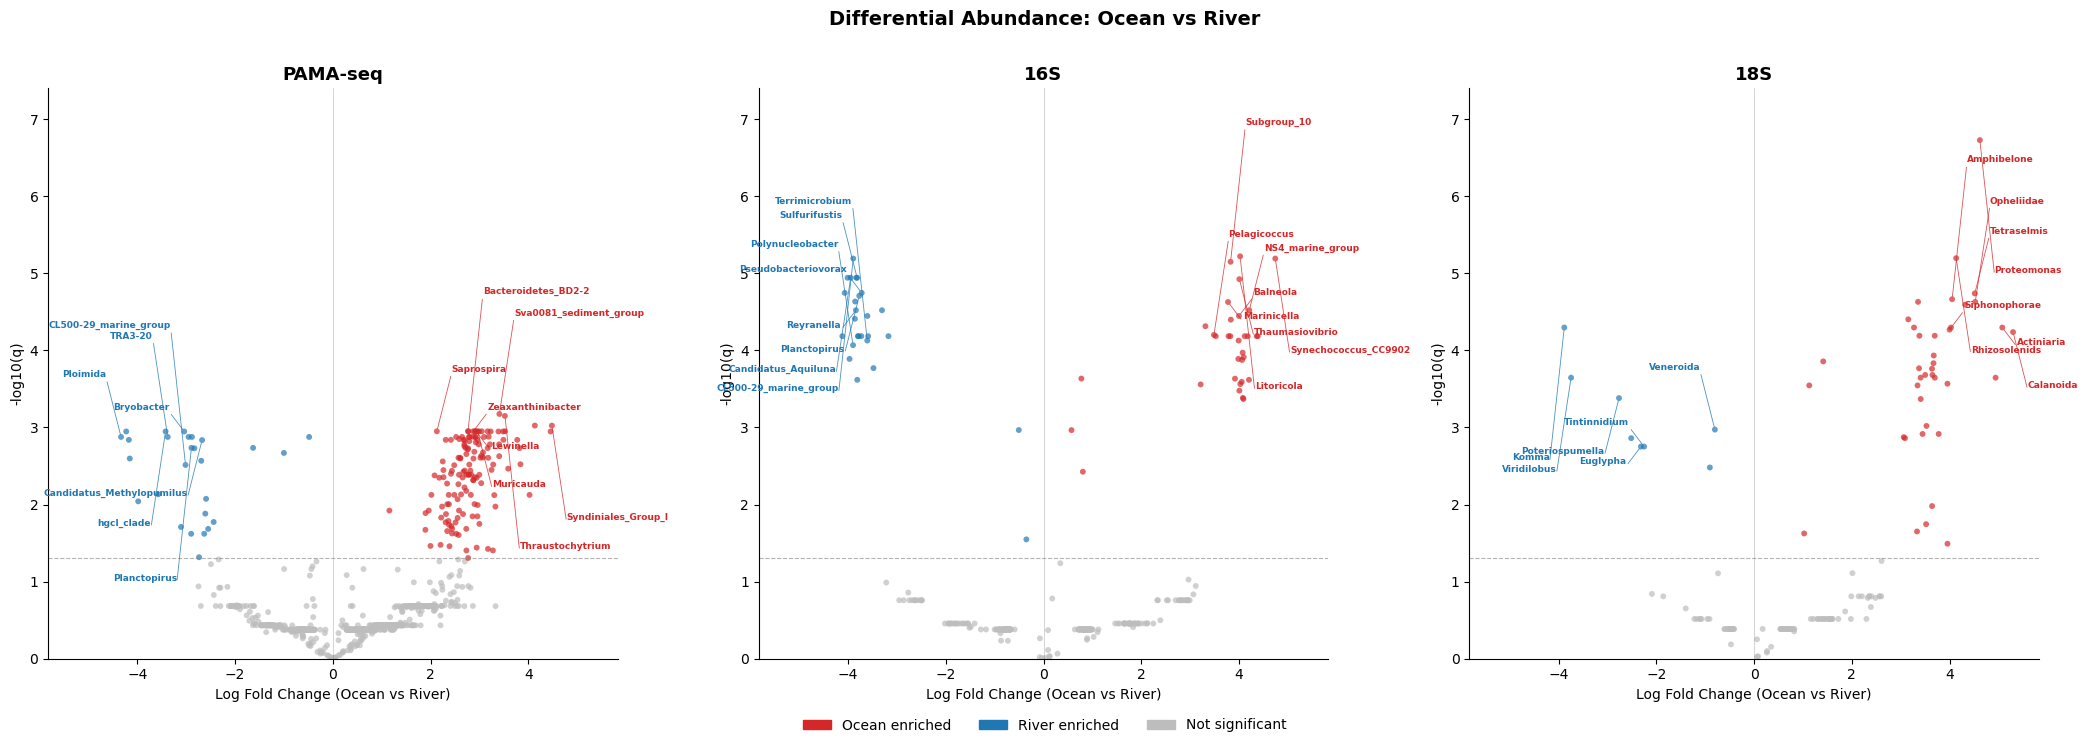

Saved: volcano_3methods_labeled.svg / .pdf / .png


In [178]:
# Generate volcano plots for all three methods with biologically meaningful genus labels
# Labels are selected based on: formal genus names, clear ecological significance,
# and consistency across methods. Discordant genera and placeholder IDs are excluded.
# Coordinates for labels are extracted automatically from the data.

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

matplotlib.rcParams['svg.fonttype'] = 'none'

# Standardize direction labels to title case
res_plot = res_all.copy()
res_plot['direction'] = res_plot['direction'].replace('river', 'River')
res_plot['-log10q'] = -np.log10(res_plot['q'].clip(lower=1e-10))

# Define biologically meaningful genera to label for each method (8 per direction)
# Only formally named genera with clear ecological significance are included
# Discordant genera (Geminigera, Cyclotella) and placeholder IDs are excluded
label_genera = {
    'PAMA': {
        'Ocean': [
            'Thraustochytrium',
            'Syndiniales_Group_I',
            'Muricauda',
            'Lewinella',
            'Zeaxanthinibacter',
            'Saprospira',
            'Sva0081_sediment_group',
            'Bacteroidetes_BD2-2',
        ],
        'River': [
            'Planctopirus',
            'hgcI_clade',
            'Candidatus_Methylopumilus',
            'Candidatus_Aquiluna',
            'Bryobacter',
            'Ploimida',
            'TRA3-20',
            'CL500-29_marine_group',
        ],
    },
    '16S': {
        'Ocean': [
            'Litoricola',
            'Synechococcus_CC9902',
            'Thaumasiovibrio',
            'Marinicella',
            'Balneola',
            'NS4_marine_group',
            'Pelagicoccus',
            'Subgroup_10',
        ],
        'River': [
            'CL500-29_marine_group',
            'Candidatus_Aquiluna',
            'Planctopirus',
            'Reyranella',
            'Pseudobacteriovorax',
            'Sulfurifustis',
            'Polynucleobacter',
            'Terrimicrobium',
        ],
    },
    '18S': {
        'Ocean': [
            'Proteomonas',
            'Rhizosolenids',
            'Calanoida',
            'Actiniaria',
            'Siphonophorae',
            'Tetraselmis',
            'Opheliidae',
            'Amphibelone',
        ],
        'River': [
            'Komma',
            'Viridilobus',
            'Poteriospumella',
            'Euglypha',
            'Tintinnidium',
            'Veneroida',
        ],
    },
}

# Auto-extract coordinates from data for each labeled genus
def get_label_coords(res_plot, sig, method, genus, direction):
    """
    Automatically extract (lfc, -log10q) coordinates for a given genus.
    Looks up the genus name in the sig dataframe and maps back to res_plot.
    Returns None if genus is not found.
    """
    row = sig[
        (sig['Method'] == method) &
        (sig['Genus'] == genus) &
        (sig['direction'] == direction)
    ]
    if len(row) == 0:
        return None
    tip = row.iloc[0]['tip']
    res_row = res_plot[
        (res_plot['Method'] == method) &
        (res_plot['tip'] == tip)
    ]
    if len(res_row) == 0:
        return None
    return (res_row.iloc[0]['lfc'], res_row.iloc[0]['-log10q'])

# Compute axis limits
x_max = res_plot['lfc'].abs().max() * 1.1
y_max = res_plot['-log10q'].max() * 1.1

method_labels = {'PAMA': 'PAMA-seq', '16S': '16S', '18S': '18S'}

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for ax, method in zip(axes, ['PAMA', '16S', '18S']):
    sub = res_plot[res_plot['Method'] == method].copy()

    # Assign colors based on significance and direction
    colors = []
    for _, row in sub.iterrows():
        if not row['significant']:
            colors.append('#bdbdbd')
        elif row['direction'] == 'Ocean':
            colors.append('#d62728')
        else:
            colors.append('#1f77b4')

    # Draw scatter plot
    ax.scatter(sub['lfc'], sub['-log10q'],
               c=colors, s=18, alpha=0.7, linewidths=0, zorder=2)

    # Draw significance threshold line and zero line
    ax.axhline(-np.log10(0.05), color='gray', linestyle='--',
               linewidth=0.8, alpha=0.6)
    ax.axvline(0, color='gray', linestyle='-',
               linewidth=0.6, alpha=0.4)

    ax.set_xlim(-x_max, x_max)
    ax.set_ylim(0, y_max)
    ax.set_title(method_labels[method], fontsize=13, fontweight='bold')
    ax.set_xlabel('Log Fold Change (Ocean vs River)', fontsize=10)
    ax.set_ylabel('-log10(q)', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Add genus labels with leader lines
    for direction, genera in label_genera[method].items():
        color = '#d62728' if direction == 'Ocean' else '#1f77b4'
        ha = 'left' if direction == 'Ocean' else 'right'
        dx = 0.3 if direction == 'Ocean' else -0.3

        for i, genus in enumerate(genera):
            coords = get_label_coords(res_plot, sig, method, genus, direction)
            if coords is None:
                print(f"Warning: {genus} not found in {method} {direction}")
                continue

            x, y = coords
            # Stagger dy to avoid label overlap
            dy = 0.5 * (i - 3.5)
            tx, ty = x + dx, y + dy

            # Draw leader line
            ax.annotate('', xy=(x, y), xytext=(tx, ty),
                        arrowprops=dict(arrowstyle='-', color=color,
                                        lw=0.6, alpha=0.8),
                        zorder=3)
            # Draw label
            ax.text(tx, ty, genus,
                    fontsize=6.5, color=color, fontweight='bold',
                    ha=ha, va='bottom', zorder=4)

# Add shared legend
legend_elements = [
    mpatches.Patch(color='#d62728', label='Ocean enriched'),
    mpatches.Patch(color='#1f77b4', label='River enriched'),
    mpatches.Patch(color='#bdbdbd', label='Not significant'),
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=3, fontsize=10, frameon=False,
           bbox_to_anchor=(0.5, -0.04))

plt.suptitle('Differential Abundance: Ocean vs River',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()

# Save in multiple formats
plt.savefig(out_dir+'volcano_3methods_labeled.svg', bbox_inches='tight', format='svg')
plt.savefig(out_dir+'volcano_3methods_labeled.pdf', bbox_inches='tight', dpi=300)
plt.savefig(out_dir+'volcano_3methods_labeled.png', bbox_inches='tight', dpi=300)
plt.show()
print("Saved: volcano_3methods_labeled.svg / .pdf / .png")

In [179]:
out_dir

'/data10/xli/project/pama-seq/OL_dif/'